In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from enum import Enum
from dataclasses import dataclass
import math
from tqdm import tqdm
import sys, inspect

from tiles import *
from utils import *
import solver as solver_import

In [2]:
def plot_schedule(schedule):
    methods = inspect.getmembers(schedule, inspect.ismethod)
    methods = [(i,j) for i,j in methods if not i.startswith('_')]

    com_ax = plt.subplot()
    com_ax.set_title('Combined')

    fig, ax = plt.subplots(1, len(methods), figsize=(3.5*len(methods), 3))

    for i, (m_name, m_func) in enumerate(methods):
        # print(i, m_name,m_func)
        g = list(map(m_func, np.arange(0,schedule.max_iter))) 
        ax[i].plot(g)
        ax[i].set_title(f'{m_name} max:{max(g):.3f} min:{min(g):.3f}')

        com_ax.plot(g)
    plt.plot()

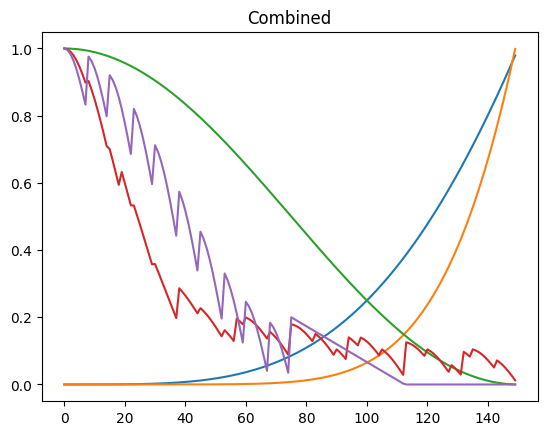

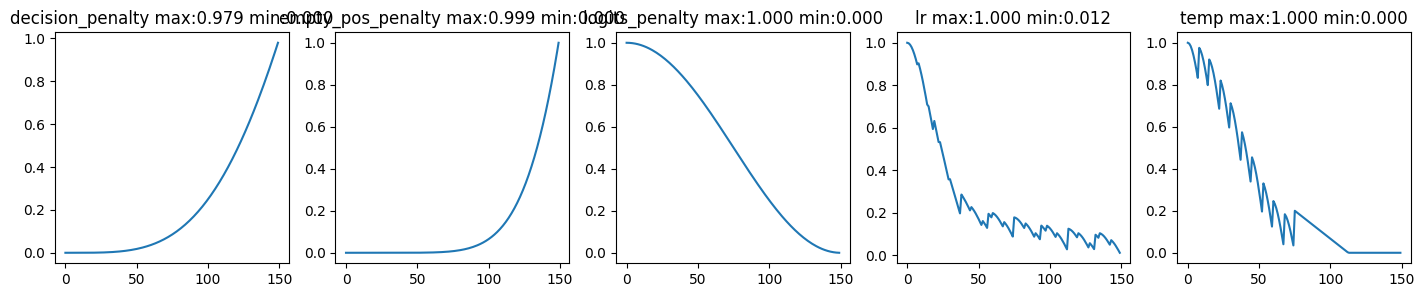

In [3]:
class Schedule:
    def __init__(self, max_iter):
        self.max_iter = max_iter
    def lr(self,x):
        x /= self.max_iter
        return ( np.cos(x*2*np.pi/4)**32 * 5 + np.cos(x*2*np.pi/4)**2 + np.cos(x*2*np.pi*5 % (np.pi/2))/5 + np.cos(x*2*np.pi*2 % (np.pi/2))/2 ) /6.7

    def temp(self,x):
        x /= self.max_iter
        if x<0.5:
            return np.maximum( np.cos(x*2*np.pi/2)**2 + np.cos(x*2*np.pi*5 % (np.pi/2))/5 , 0.001) / 1.2
        else:
            return max(0.2*(1-(x-0.5)*4),0)
    def logits_penalty(self,x):
        x /= self.max_iter
        return np.cos(x*np.pi/2)**2 
    
    def decision_penalty(self,x):
        x /= self.max_iter

        x /=2
        return np.cos(x*np.pi/2 + 1/2*np.pi)**4 *4
    def empty_pos_penalty(self,x):
        x /= self.max_iter

        x /=2
        return np.cos(x*np.pi/2 + 1/2*np.pi)**8 *4 / 0.24

schedule = Schedule(150)
plot_schedule(schedule)

In [7]:
BOX_SIZE = 15
INPUT_POS = (0,3)
OUT_POS = (13, 12)
NEG_INF = -500.0

In [8]:
import importlib
importlib.reload(solver_import) # Fast reaload

solver = solver_import.FactorioSolver(BOX_SIZE, DEFAULT_TILE_DATA)

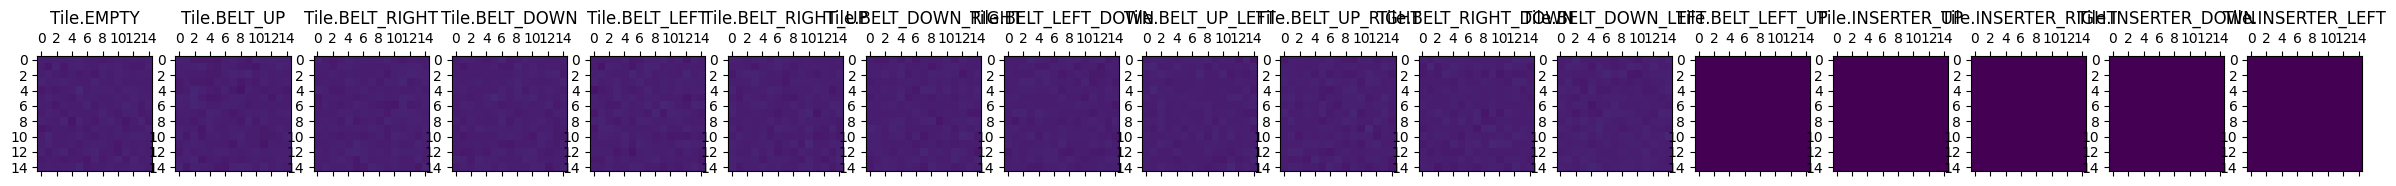

0.0% Loss comb:-19905.031, Path loss:14.674, Belt penalty:0.70, Inser penalty:4000000.00, Logits penalty: 117.06, Logits penalty1: 117.06, Decision penalty: 0.00 Empty:0.00
0.7% Loss comb:-19845.613, Path loss:12.453, Belt penalty:0.64, Inser penalty:4000000.00, Logits penalty: 186.55, Logits penalty1: 186.55, Decision penalty: 0.00 Empty:-0.00
1.3% Loss comb:-19902.010, Path loss:12.069, Belt penalty:0.65, Inser penalty:4000000.00, Logits penalty: 125.70, Logits penalty1: 125.70, Decision penalty: 0.00 Empty:-0.00
2.0% Loss comb:-19895.566, Path loss:13.650, Belt penalty:0.66, Inser penalty:4000000.00, Logits penalty: 127.20, Logits penalty1: 127.20, Decision penalty: 0.00 Empty:0.00
2.6% Loss comb:-19875.854, Path loss:14.278, Belt penalty:0.65, Inser penalty:4000000.00, Logits penalty: 146.02, Logits penalty1: 146.02, Decision penalty: 0.00 Empty:0.00
3.3% Loss comb:-19884.062, Path loss:12.749, Belt penalty:0.64, Inser penalty:4000000.00, Logits penalty: 140.37, Logits penalty1: 14

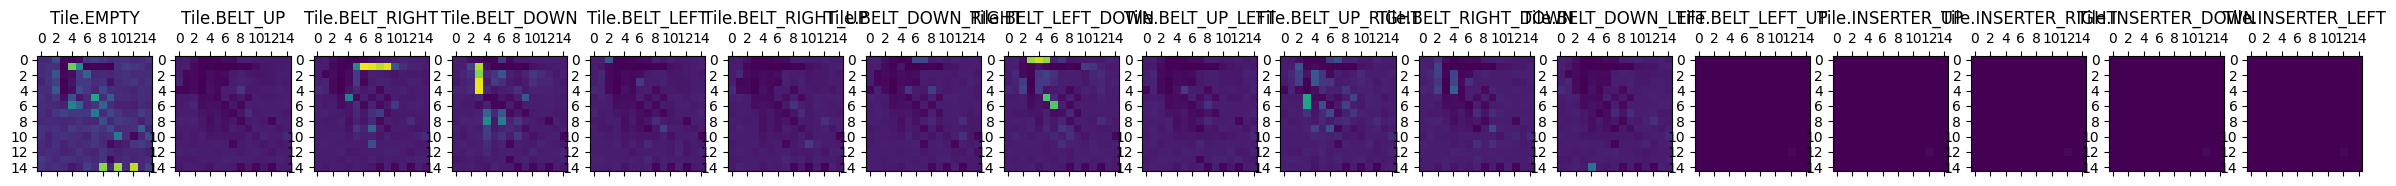

6.6% Loss comb:-19895.709, Path loss:10.750, Belt penalty:0.63, Inser penalty:4000000.00, Logits penalty: 135.32, Logits penalty1: 135.32, Decision penalty: 0.00 Empty:-0.00
7.3% Loss comb:-19901.383, Path loss:10.495, Belt penalty:0.64, Inser penalty:4000000.00, Logits penalty: 129.27, Logits penalty1: 129.27, Decision penalty: 0.00 Empty:-0.00
7.9% Loss comb:-19907.348, Path loss:10.358, Belt penalty:0.65, Inser penalty:4000000.00, Logits penalty: 122.50, Logits penalty1: 122.50, Decision penalty: 0.00 Empty:-0.00
8.6% Loss comb:-19909.307, Path loss:10.243, Belt penalty:0.65, Inser penalty:4000000.00, Logits penalty: 119.83, Logits penalty1: 119.83, Decision penalty: 0.00 Empty:-0.00
9.3% Loss comb:-19908.994, Path loss:10.101, Belt penalty:0.66, Inser penalty:4000000.00, Logits penalty: 119.60, Logits penalty1: 119.60, Decision penalty: 0.00 Empty:-0.00
9.9% Loss comb:-19907.779, Path loss:9.584, Belt penalty:0.66, Inser penalty:4000000.00, Logits penalty: 120.85, Logits penalty1: 

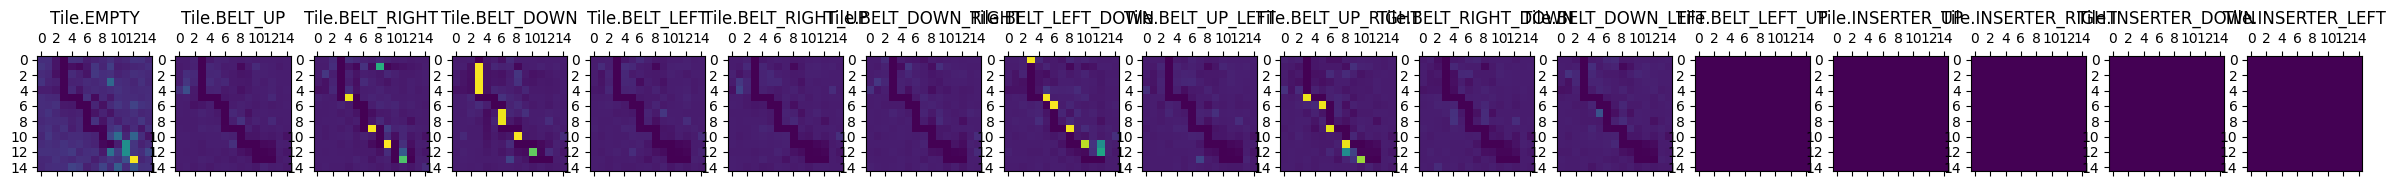

13.2% Loss comb:-19919.959, Path loss:0.452, Belt penalty:0.64, Inser penalty:4000000.00, Logits penalty: 120.77, Logits penalty1: 120.77, Decision penalty: 0.00 Empty:-0.00
13.9% Loss comb:-19921.078, Path loss:0.320, Belt penalty:0.63, Inser penalty:4000000.00, Logits penalty: 120.42, Logits penalty1: 120.42, Decision penalty: 0.01 Empty:-0.00
14.6% Loss comb:-19921.805, Path loss:0.297, Belt penalty:0.63, Inser penalty:4000000.00, Logits penalty: 120.13, Logits penalty1: 120.13, Decision penalty: 0.01 Empty:-0.00
15.2% Loss comb:-19922.162, Path loss:0.328, Belt penalty:0.63, Inser penalty:4000000.00, Logits penalty: 119.91, Logits penalty1: 119.91, Decision penalty: 0.01 Empty:-0.00
15.9% Loss comb:-19922.734, Path loss:0.402, Belt penalty:0.63, Inser penalty:4000000.00, Logits penalty: 119.23, Logits penalty1: 119.23, Decision penalty: 0.01 Empty:-0.00
16.6% Loss comb:-19923.674, Path loss:0.495, Belt penalty:0.63, Inser penalty:4000000.00, Logits penalty: 118.00, Logits penalty1:

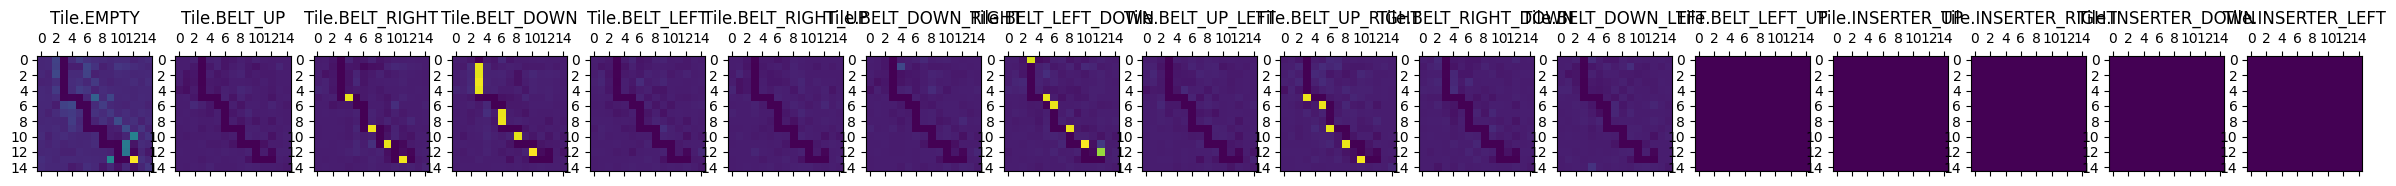

19.9% Loss comb:-19928.291, Path loss:0.577, Belt penalty:0.64, Inser penalty:4000000.00, Logits penalty: 112.06, Logits penalty1: 112.06, Decision penalty: 0.02 Empty:-0.00
20.5% Loss comb:-19929.084, Path loss:0.548, Belt penalty:0.65, Inser penalty:4000000.00, Logits penalty: 111.17, Logits penalty1: 111.17, Decision penalty: 0.02 Empty:-0.00
21.2% Loss comb:-19929.924, Path loss:0.521, Belt penalty:0.65, Inser penalty:4000000.00, Logits penalty: 110.29, Logits penalty1: 110.29, Decision penalty: 0.03 Empty:-0.00
21.9% Loss comb:-19930.812, Path loss:0.497, Belt penalty:0.65, Inser penalty:4000000.00, Logits penalty: 109.39, Logits penalty1: 109.39, Decision penalty: 0.03 Empty:-0.00
22.5% Loss comb:-19931.756, Path loss:0.477, Belt penalty:0.65, Inser penalty:4000000.00, Logits penalty: 108.47, Logits penalty1: 108.47, Decision penalty: 0.04 Empty:-0.00
23.2% Loss comb:-19932.730, Path loss:0.463, Belt penalty:0.65, Inser penalty:4000000.00, Logits penalty: 107.53, Logits penalty1:

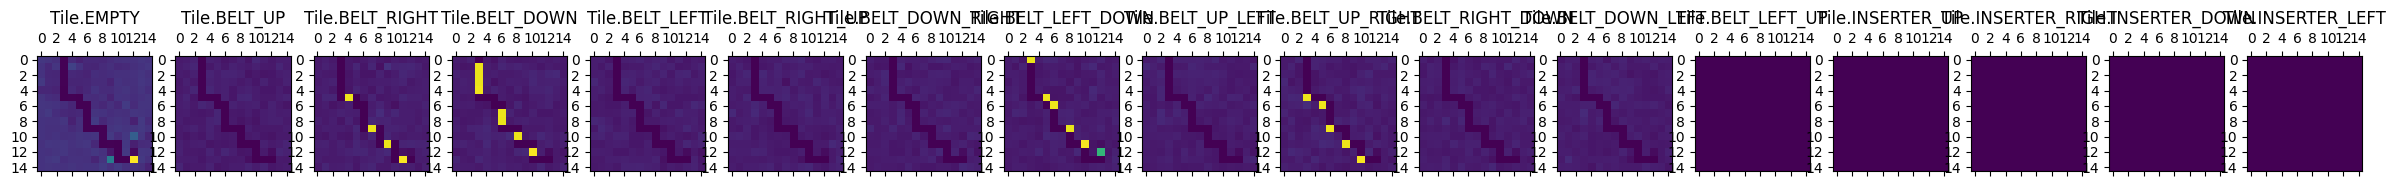

26.5% Loss comb:-19937.674, Path loss:0.450, Belt penalty:0.63, Inser penalty:4000000.00, Logits penalty: 102.86, Logits penalty1: 102.86, Decision penalty: 0.07 Empty:-0.00
27.2% Loss comb:-19938.666, Path loss:0.452, Belt penalty:0.63, Inser penalty:4000000.00, Logits penalty: 101.93, Logits penalty1: 101.93, Decision penalty: 0.08 Empty:-0.00
27.8% Loss comb:-19939.670, Path loss:0.452, Belt penalty:0.63, Inser penalty:4000000.00, Logits penalty: 100.99, Logits penalty1: 100.99, Decision penalty: 0.08 Empty:-0.00
28.5% Loss comb:-19940.689, Path loss:0.450, Belt penalty:0.63, Inser penalty:4000000.00, Logits penalty: 100.02, Logits penalty1: 100.02, Decision penalty: 0.09 Empty:-0.00
29.1% Loss comb:-19941.729, Path loss:0.447, Belt penalty:0.63, Inser penalty:4000000.00, Logits penalty: 99.02, Logits penalty1: 99.02, Decision penalty: 0.10 Empty:-0.00
29.8% Loss comb:-19942.785, Path loss:0.443, Belt penalty:0.63, Inser penalty:4000000.00, Logits penalty: 97.98, Logits penalty1: 97

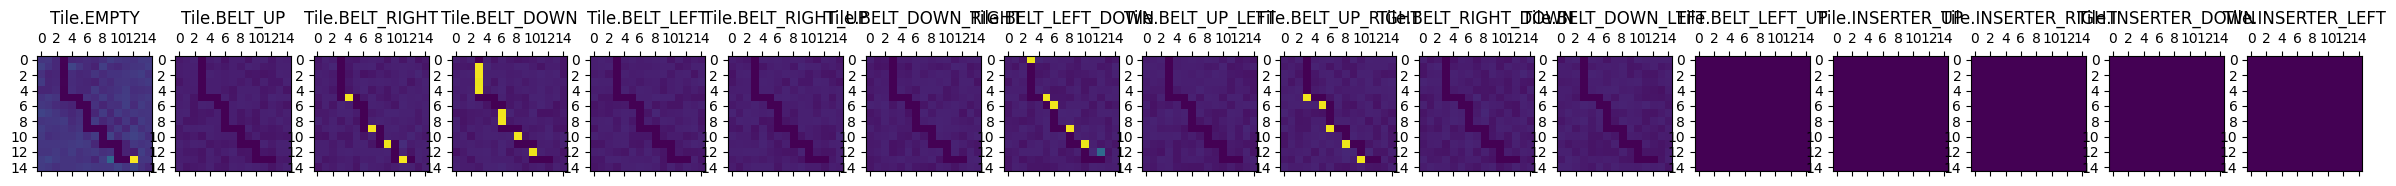

33.1% Loss comb:-19948.264, Path loss:0.440, Belt penalty:0.63, Inser penalty:4000000.00, Logits penalty: 92.48, Logits penalty1: 92.48, Decision penalty: 0.17 Empty:-0.00
33.8% Loss comb:-19949.391, Path loss:0.442, Belt penalty:0.63, Inser penalty:4000000.00, Logits penalty: 91.33, Logits penalty1: 91.33, Decision penalty: 0.18 Empty:-0.00
34.4% Loss comb:-19950.527, Path loss:0.443, Belt penalty:0.63, Inser penalty:4000000.00, Logits penalty: 90.17, Logits penalty1: 90.17, Decision penalty: 0.19 Empty:-0.00
35.1% Loss comb:-19951.678, Path loss:0.443, Belt penalty:0.63, Inser penalty:4000000.00, Logits penalty: 88.99, Logits penalty1: 88.99, Decision penalty: 0.21 Empty:-0.00
35.8% Loss comb:-19952.840, Path loss:0.442, Belt penalty:0.63, Inser penalty:4000000.00, Logits penalty: 87.82, Logits penalty1: 87.82, Decision penalty: 0.22 Empty:-0.01
36.4% Loss comb:-19954.004, Path loss:0.440, Belt penalty:0.63, Inser penalty:4000000.00, Logits penalty: 86.64, Logits penalty1: 86.64, Dec

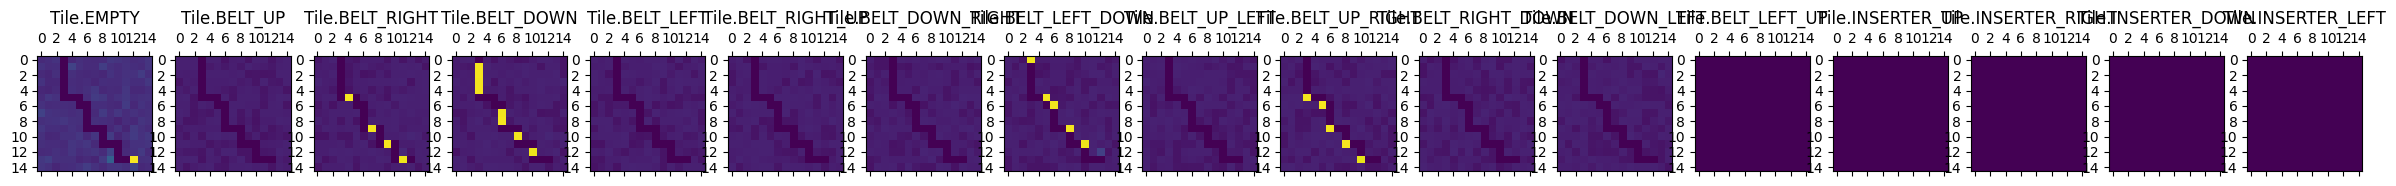

39.7% Loss comb:-19959.973, Path loss:0.394, Belt penalty:0.64, Inser penalty:4000000.00, Logits penalty: 80.74, Logits penalty1: 80.74, Decision penalty: 0.34 Empty:-0.01
40.4% Loss comb:-19961.193, Path loss:0.378, Belt penalty:0.64, Inser penalty:4000000.00, Logits penalty: 79.57, Logits penalty1: 79.57, Decision penalty: 0.36 Empty:-0.01
41.1% Loss comb:-19962.424, Path loss:0.361, Belt penalty:0.64, Inser penalty:4000000.00, Logits penalty: 78.39, Logits penalty1: 78.39, Decision penalty: 0.39 Empty:-0.01
41.7% Loss comb:-19963.664, Path loss:0.345, Belt penalty:0.64, Inser penalty:4000000.00, Logits penalty: 77.20, Logits penalty1: 77.20, Decision penalty: 0.41 Empty:-0.02
42.4% Loss comb:-19964.906, Path loss:0.328, Belt penalty:0.63, Inser penalty:4000000.00, Logits penalty: 76.01, Logits penalty1: 76.01, Decision penalty: 0.44 Empty:-0.02
43.0% Loss comb:-19966.162, Path loss:0.313, Belt penalty:0.63, Inser penalty:4000000.00, Logits penalty: 74.81, Logits penalty1: 74.81, Dec

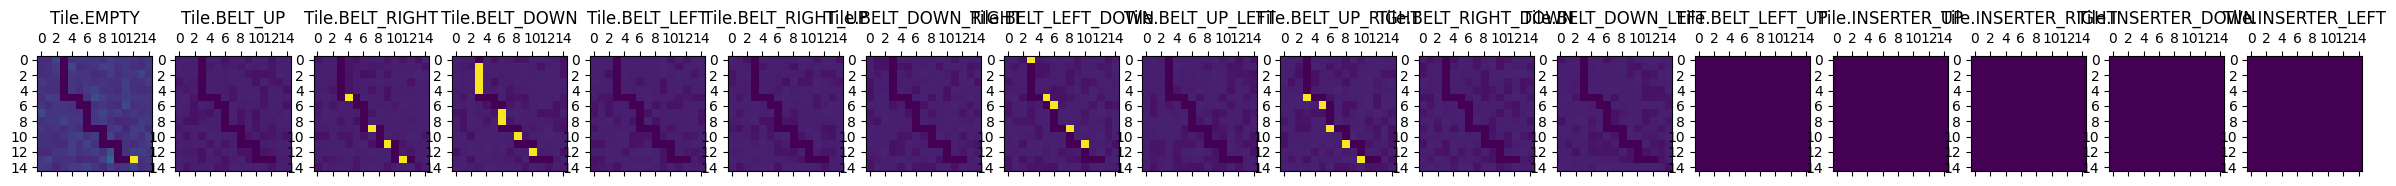

46.4% Loss comb:-19972.510, Path loss:0.249, Belt penalty:0.62, Inser penalty:4000000.00, Logits penalty: 68.74, Logits penalty1: 68.74, Decision penalty: 0.63 Empty:-0.05
47.0% Loss comb:-19973.795, Path loss:0.238, Belt penalty:0.62, Inser penalty:4000000.00, Logits penalty: 67.53, Logits penalty1: 67.53, Decision penalty: 0.67 Empty:-0.05
47.7% Loss comb:-19975.080, Path loss:0.228, Belt penalty:0.62, Inser penalty:4000000.00, Logits penalty: 66.31, Logits penalty1: 66.31, Decision penalty: 0.71 Empty:-0.06
48.3% Loss comb:-19976.377, Path loss:0.220, Belt penalty:0.62, Inser penalty:4000000.00, Logits penalty: 65.08, Logits penalty1: 65.08, Decision penalty: 0.75 Empty:-0.07
49.0% Loss comb:-19977.670, Path loss:0.212, Belt penalty:0.61, Inser penalty:4000000.00, Logits penalty: 63.85, Logits penalty1: 63.85, Decision penalty: 0.79 Empty:-0.08
49.7% Loss comb:-19978.967, Path loss:0.205, Belt penalty:0.61, Inser penalty:4000000.00, Logits penalty: 62.61, Logits penalty1: 62.61, Dec

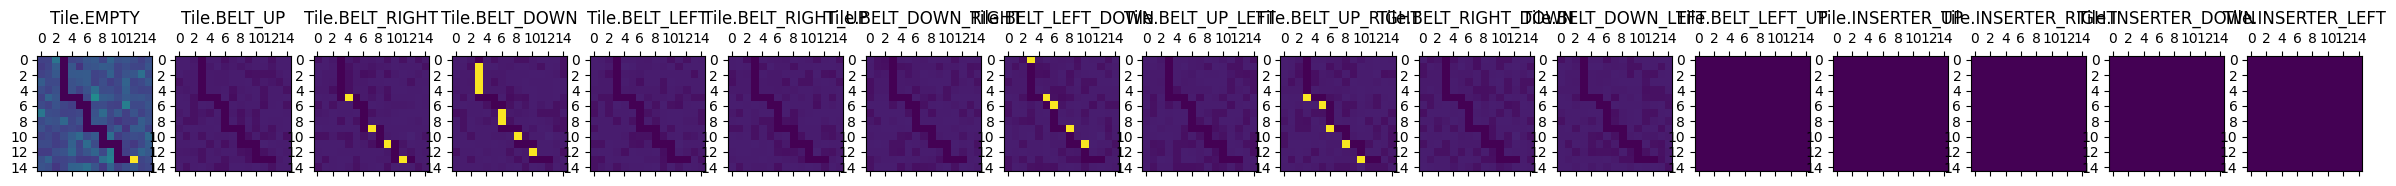

53.0% Loss comb:-19985.660, Path loss:0.146, Belt penalty:0.57, Inser penalty:4000000.00, Logits penalty: 56.99, Logits penalty1: 56.99, Decision penalty: 1.10 Empty:-0.21
53.6% Loss comb:-19987.047, Path loss:0.137, Belt penalty:0.55, Inser penalty:4000000.00, Logits penalty: 55.90, Logits penalty1: 55.90, Decision penalty: 1.17 Empty:-0.24
54.3% Loss comb:-19988.455, Path loss:0.129, Belt penalty:0.54, Inser penalty:4000000.00, Logits penalty: 54.83, Logits penalty1: 54.83, Decision penalty: 1.24 Empty:-0.28
55.0% Loss comb:-19989.893, Path loss:0.122, Belt penalty:0.52, Inser penalty:4000000.00, Logits penalty: 53.77, Logits penalty1: 53.77, Decision penalty: 1.31 Empty:-0.33
55.6% Loss comb:-19991.402, Path loss:0.114, Belt penalty:0.50, Inser penalty:4000000.00, Logits penalty: 52.80, Logits penalty1: 52.80, Decision penalty: 1.39 Empty:-0.39
56.3% Loss comb:-19992.975, Path loss:0.107, Belt penalty:0.48, Inser penalty:4000000.00, Logits penalty: 51.88, Logits penalty1: 51.88, Dec

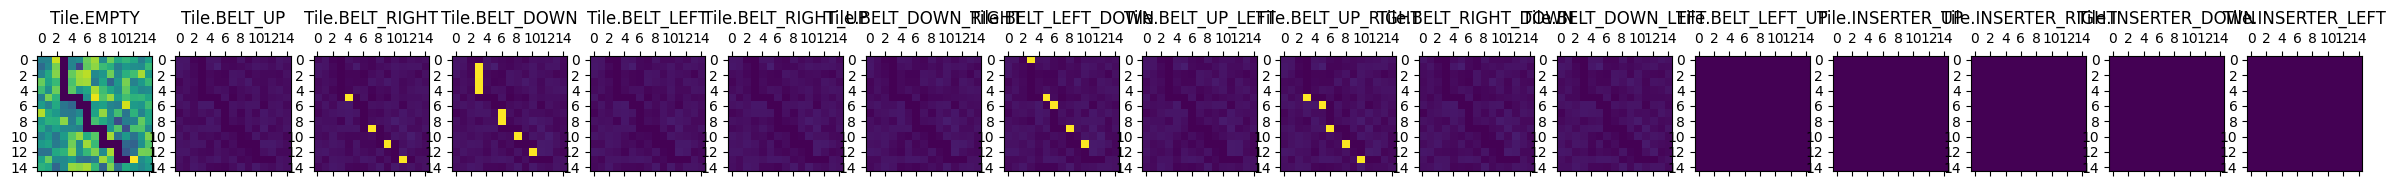

59.6% Loss comb:-20001.943, Path loss:0.081, Belt penalty:0.33, Inser penalty:4000000.00, Logits penalty: 47.71, Logits penalty1: 47.71, Decision penalty: 2.09 Empty:-1.02
60.3% Loss comb:-20004.105, Path loss:0.076, Belt penalty:0.30, Inser penalty:4000000.00, Logits penalty: 47.06, Logits penalty1: 47.06, Decision penalty: 2.27 Empty:-1.19
60.9% Loss comb:-20006.359, Path loss:0.072, Belt penalty:0.27, Inser penalty:4000000.00, Logits penalty: 46.44, Logits penalty1: 46.44, Decision penalty: 2.47 Empty:-1.38
61.6% Loss comb:-20008.666, Path loss:0.068, Belt penalty:0.24, Inser penalty:4000000.00, Logits penalty: 45.80, Logits penalty1: 45.80, Decision penalty: 2.68 Empty:-1.60
62.3% Loss comb:-20010.992, Path loss:0.065, Belt penalty:0.21, Inser penalty:4000000.00, Logits penalty: 45.11, Logits penalty1: 45.11, Decision penalty: 2.91 Empty:-1.83
62.9% Loss comb:-20014.293, Path loss:0.059, Belt penalty:0.17, Inser penalty:4000000.00, Logits penalty: 45.16, Logits penalty1: 45.16, Dec

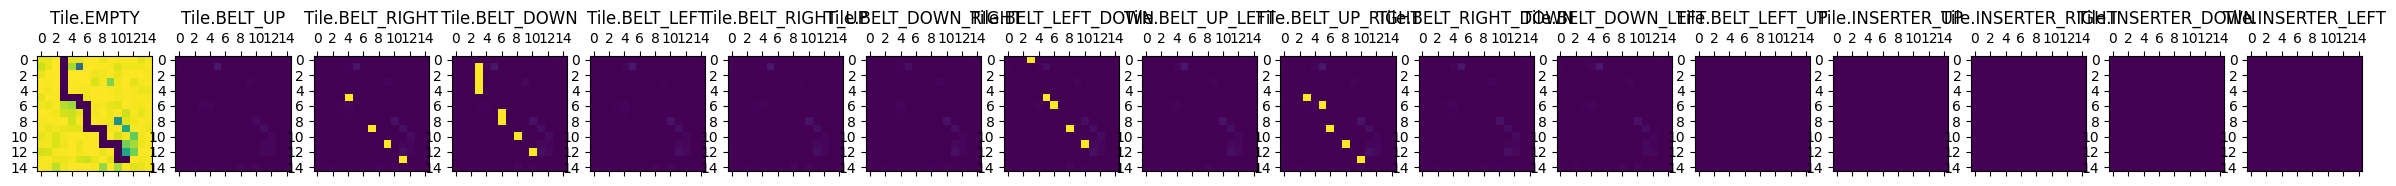

66.2% Loss comb:-20032.623, Path loss:0.036, Belt penalty:0.07, Inser penalty:4000000.00, Logits penalty: 46.42, Logits penalty1: 46.42, Decision penalty: 6.21 Empty:-4.73
66.9% Loss comb:-20036.467, Path loss:0.033, Belt penalty:0.06, Inser penalty:4000000.00, Logits penalty: 46.85, Logits penalty1: 46.85, Decision penalty: 7.04 Empty:-5.38
67.5% Loss comb:-20040.166, Path loss:0.030, Belt penalty:0.05, Inser penalty:4000000.00, Logits penalty: 47.16, Logits penalty1: 47.16, Decision penalty: 7.91 Empty:-6.05
68.2% Loss comb:-20043.703, Path loss:0.027, Belt penalty:0.05, Inser penalty:4000000.00, Logits penalty: 47.28, Logits penalty1: 47.28, Decision penalty: 8.80 Empty:-6.73
68.9% Loss comb:-20047.062, Path loss:0.025, Belt penalty:0.05, Inser penalty:4000000.00, Logits penalty: 47.17, Logits penalty1: 47.17, Decision penalty: 9.70 Empty:-7.41
69.5% Loss comb:-20050.240, Path loss:0.023, Belt penalty:0.05, Inser penalty:4000000.00, Logits penalty: 46.80, Logits penalty1: 46.80, Dec

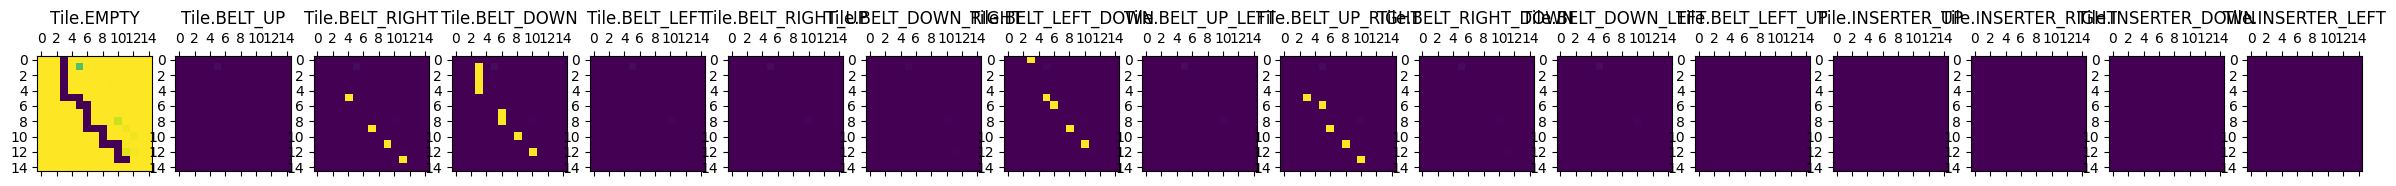

72.8% Loss comb:-20065.861, Path loss:0.016, Belt penalty:0.04, Inser penalty:4000000.00, Logits penalty: 43.99, Logits penalty1: 43.99, Decision penalty: 15.84 Empty:-11.65
73.5% Loss comb:-20068.680, Path loss:0.015, Belt penalty:0.04, Inser penalty:4000000.00, Logits penalty: 42.73, Logits penalty1: 42.73, Decision penalty: 16.79 Empty:-12.45
74.2% Loss comb:-20071.396, Path loss:0.014, Belt penalty:0.04, Inser penalty:4000000.00, Logits penalty: 41.25, Logits penalty1: 41.25, Decision penalty: 17.67 Empty:-13.29
74.8% Loss comb:-20073.996, Path loss:0.014, Belt penalty:0.04, Inser penalty:4000000.00, Logits penalty: 39.59, Logits penalty1: 39.59, Decision penalty: 18.47 Empty:-14.16
75.5% Loss comb:-20077.490, Path loss:0.012, Belt penalty:0.04, Inser penalty:4000000.00, Logits penalty: 39.13, Logits penalty1: 39.13, Decision penalty: 20.14 Empty:-15.13
76.2% Loss comb:-20080.945, Path loss:0.011, Belt penalty:0.04, Inser penalty:4000000.00, Logits penalty: 38.55, Logits penalty1: 

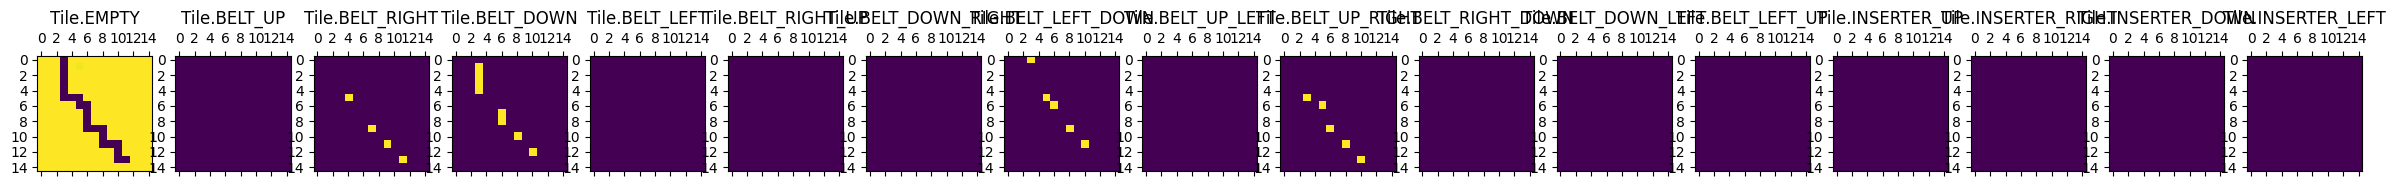

79.5% Loss comb:-20097.336, Path loss:0.006, Belt penalty:0.04, Inser penalty:4000000.00, Logits penalty: 33.43, Logits penalty1: 33.43, Decision penalty: 30.87 Empty:-22.06
80.1% Loss comb:-20100.611, Path loss:0.006, Belt penalty:0.04, Inser penalty:4000000.00, Logits penalty: 32.24, Logits penalty1: 32.24, Decision penalty: 32.93 Empty:-23.43
80.8% Loss comb:-20103.842, Path loss:0.005, Belt penalty:0.04, Inser penalty:4000000.00, Logits penalty: 30.95, Logits penalty1: 30.95, Decision penalty: 35.01 Empty:-24.86
81.5% Loss comb:-20107.025, Path loss:0.005, Belt penalty:0.04, Inser penalty:4000000.00, Logits penalty: 29.55, Logits penalty1: 29.55, Decision penalty: 37.09 Empty:-26.37
82.1% Loss comb:-20110.143, Path loss:0.004, Belt penalty:0.04, Inser penalty:4000000.00, Logits penalty: 28.07, Logits penalty1: 28.07, Decision penalty: 39.14 Empty:-27.95
82.8% Loss comb:-20113.188, Path loss:0.004, Belt penalty:0.04, Inser penalty:4000000.00, Logits penalty: 26.50, Logits penalty1: 

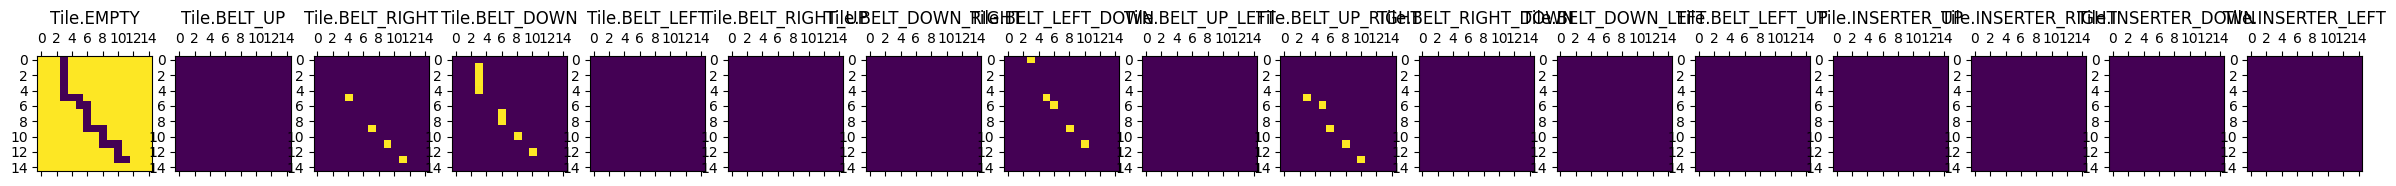

86.1% Loss comb:-20127.551, Path loss:0.003, Belt penalty:0.04, Inser penalty:4000000.00, Logits penalty: 18.23, Logits penalty1: 18.23, Decision penalty: 50.58 Empty:-38.96
86.8% Loss comb:-20130.311, Path loss:0.003, Belt penalty:0.04, Inser penalty:4000000.00, Logits penalty: 16.63, Logits penalty1: 16.63, Decision penalty: 52.47 Empty:-41.09
87.4% Loss comb:-20132.984, Path loss:0.003, Belt penalty:0.04, Inser penalty:4000000.00, Logits penalty: 15.05, Logits penalty1: 15.05, Decision penalty: 54.25 Empty:-43.29
88.1% Loss comb:-20136.092, Path loss:0.002, Belt penalty:0.04, Inser penalty:4000000.00, Logits penalty: 13.75, Logits penalty1: 13.75, Decision penalty: 57.07 Empty:-45.71
88.7% Loss comb:-20139.133, Path loss:0.002, Belt penalty:0.04, Inser penalty:4000000.00, Logits penalty: 12.45, Logits penalty1: 12.45, Decision penalty: 59.88 Empty:-48.24
89.4% Loss comb:-20142.094, Path loss:0.002, Belt penalty:0.04, Inser penalty:4000000.00, Logits penalty: 11.17, Logits penalty1: 

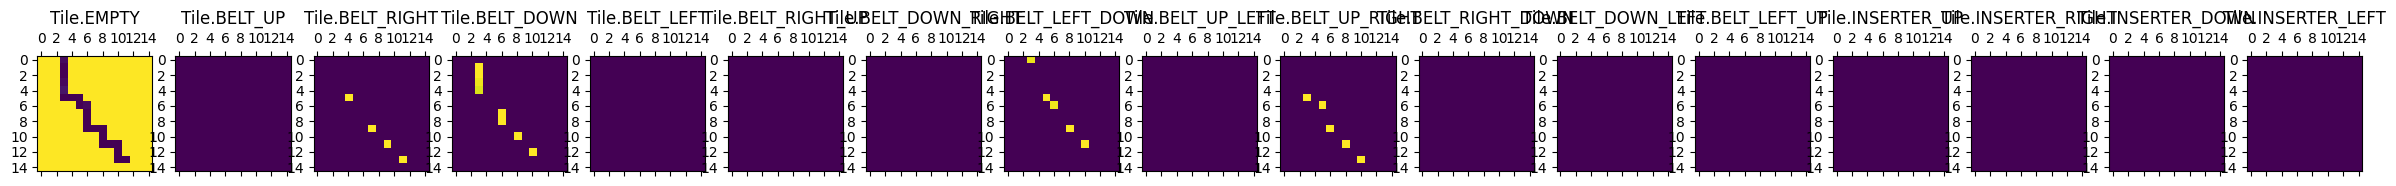

92.7% Loss comb:-20156.447, Path loss:0.001, Belt penalty:0.04, Inser penalty:4000000.00, Logits penalty: 5.50, Logits penalty1: 5.50, Decision penalty: 78.45 Empty:-65.73
93.4% Loss comb:-20159.023, Path loss:0.001, Belt penalty:0.04, Inser penalty:4000000.00, Logits penalty: 4.52, Logits penalty1: 4.52, Decision penalty: 81.40 Empty:-68.97
94.0% Loss comb:-20161.498, Path loss:0.001, Belt penalty:0.04, Inser penalty:4000000.00, Logits penalty: 3.61, Logits penalty1: 3.61, Decision penalty: 84.22 Empty:-72.30
94.7% Loss comb:-20163.889, Path loss:0.001, Belt penalty:0.04, Inser penalty:4000000.00, Logits penalty: 2.79, Logits penalty1: 2.79, Decision penalty: 86.89 Empty:-75.72
95.4% Loss comb:-20166.281, Path loss:0.001, Belt penalty:0.04, Inser penalty:4000000.00, Logits penalty: 2.07, Logits penalty1: 2.07, Decision penalty: 89.86 Empty:-79.30
96.0% Loss comb:-20168.600, Path loss:0.001, Belt penalty:0.04, Inser penalty:4000000.00, Logits penalty: 1.45, Logits penalty1: 1.45, Decis

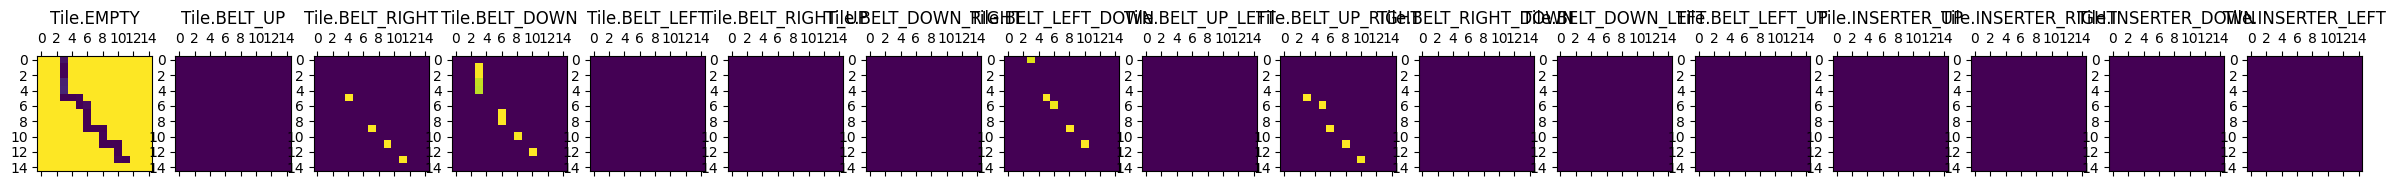

99.3% Loss comb:-20179.553, Path loss:0.001, Belt penalty:0.04, Inser penalty:4000000.00, Logits penalty: 0.00, Logits penalty1: 0.00, Decision penalty: 105.28 Empty:-103.13


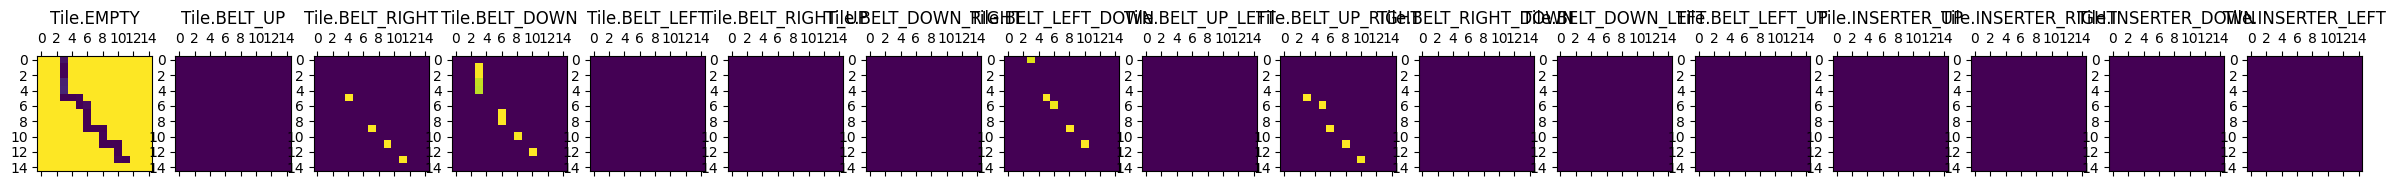

In [24]:
logits = torch.full((BOX_SIZE,BOX_SIZE,len(Tile)), -500.0)
active_tiles = list(range(0,12+1))

logits[:,:,active_tiles] = 5 * torch.randn(BOX_SIZE,BOX_SIZE,len(active_tiles))

logits.requires_grad_()
# solve = smax(solve)

add_tensor = torch.zeros(BOX_SIZE,BOX_SIZE)
add_tensor[INPUT_POS[0], INPUT_POS[1]] = 100

MAX_ITER = 151
START_TEMP = 100

opt = torch.optim.Adam([logits],lr=100)
# opt = torch.optim.SGD([logits], lr=20,momentum=0.98,nesterov=True)
# opt = torch.optim.RMSprop([logits],lr=5, momentum=0.98)
# sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=MAX_ITER)
for iter in range(MAX_ITER):
    for g in opt.param_groups:
        g['lr'] = 100 * schedule.lr(iter)

    logits_noise = logits + 0.01 * schedule.temp(iter) * torch.randn_like(logits)
    with torch.no_grad():
        logits_noise[:, :, 12::] = -200
    solve = torch.nn.functional.log_softmax(logits_noise/50,dim=-1)
    # solve = gumbel_softmax_log(logits_noise,temperature=5)

    if iter%10==0:
        plot_solve(solve)
    items = solver.eval(solve,add_tensor, max_iter=BOX_SIZE*1.8)
    # path_loss = -items[0, 13, :].mean(dim=-1)
    path_loss = -( items[OUT_POS[0], OUT_POS[1], :].max(dim=-1)[0] - np.log(100) )

    inserter_penalty = (logits_noise[:,:,[i.value for i in Tile.INSERTERS()]]**2).mean() * 100 # * 3.5 # 
    inserter_penalty1 = (logits_noise[:,:,[i.value for i in Tile.INSERTERS()]]).mean() * 100 # * 3.5 # 
    # belt_penalty = (logits_noise[:,:,[i.value for i in Tile.BELTS()]]**2).mean() * 1 *0.001
    belt_penalty = (torch.sigmoid(solve[:,:,[i.value for i in Tile.BELTS()]])).mean() * 1 * 10
    # belt_penalty = (torch.sigmoid(solve[:,:,[i.value for i in Tile.BELTS()]])).mean() * 1 * 10

    # inserter_penalty += (solve[:,:,[i.value for i in Tile.INSERTERS()]]).exp().mean() * 7000 * 10 # * 3.5 #  # 
    # belt_penalty += (solve[:,:,[i.value for i in Tile.BELTS()]]).exp().mean() * 1

    logits_penalty = (torch.clamp(logits_noise**2,min=200.0)-200.0).mean() * 0.01 * schedule.logits_penalty(iter)
    logits_penalty1 = (solve[:,:,1::]).mean() * 10#  * schedule.logits_penalty(iter)
    
    empty_pos_penalty = -(torch.clamp(logits_noise[:,:,0],max=400)).mean() * 1 /4 * schedule.empty_pos_penalty(iter)
    dec_penalty = (torch.minimum(1-solve,solve-1)**2).mean() * 0.3 * schedule.decision_penalty(iter)
    
    loss = path_loss + inserter_penalty1 + belt_penalty + dec_penalty +logits_penalty + empty_pos_penalty + logits_penalty1# + + dec_penalty 
    loss.backward()
    opt.step()

    grad_norm = logits.grad.abs().mean().item()
    empty_ratio = (solve[:, :, 0] > -0.5).float().mean().item()
    # print(loss.item(), path_loss.item(),belt_penalty.item(),inserter_penalty.item(),temp, grad_norm, empty_ratio, sch.get_last_lr()[0])
    print(f'{iter/MAX_ITER*100:.1f}% Loss comb:{loss.item():.3f}, Path loss:{path_loss:.3f}, Belt penalty:{belt_penalty:.2f}, Inser penalty:{inserter_penalty:.2f}, Logits penalty: {logits_penalty:.2f}, Logits penalty1: {logits_penalty:.2f}, Decision penalty: {dec_penalty:.2f} Empty:{empty_pos_penalty:.2f}')

    opt.zero_grad()
    # sch.step()

plot_solve(solve)

In [ ]:
solver.eval(solve, iter_add=add_tensor, verbose=10,max_iter=20)

In [ ]:
render_solve(solve)